In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from typing import Optional
import torch.nn.functional as F

from model import Transformer, make_src_mask, make_tgt_mask

from tqdm import tqdm
from nltk.translate.bleu_score import corpus_bleu

from dataset import *
from lr_scheduler import *
from train import *

import wandb

In [ ]:
transformer = run_training_experiment()

In [2]:
config = {
        "grid_size"        : 128,
        "patch_size"       : 4,
        "patch_dim"        : 4 * 4 * 2,
        "d_model"          : 256,
        "N"                : 8,
        "num_heads"        : 8,
        "d_ff"             : 1024,
        "dropout"          : 0.1,
        "train_batch_size" : 2,
        "test_batch_size"  : 32,
        "epochs"           : 15,
        "device"           : 'cuda' if torch.cuda.is_available() else 'cpu',
        'save_every'       : 4,
    }

transformer = Transformer(
                        d_model        = config["d_model"], 
                        N              = config["N"], 
                        num_heads      = config["num_heads"], 
                        d_ff           = config["d_ff"],
                        patch_dim      = config['patch_dim'])

In [3]:
load_checkpoint("checkpoint-2.pt", transformer)

99

In [4]:
cfd_dataset   = CFD_Dataset(root = "Data", patch_size = 4, grid_size = 128)
dataloader    = DataLoader(cfd_dataset, batch_size = 1, shuffle = True)

src, tgt = next(iter(dataloader))

pred_patches = greedy_decode(transformer, src, src_mask=make_src_mask(src, -1), max_len = (config["grid_size"]//config["patch_size"])**2, patch_dim = config["patch_dim"])
pred_patches.shape

100%|██████████| 1024/1024 [05:09<00:00,  3.31it/s]


torch.Size([1, 1024, 32])

In [5]:
src, tgt = next(iter(dataloader))

In [6]:
def patches_to_contour(patch, num_patches, patch_size, grid_size):

    unrolled = patch.view(num_patches, num_patches, 2, patch_size, patch_size)   # (patch_row, patch_col, C, patch_h, patch_w)
    unrolled = unrolled.permute(2, 0, 3, 1, 4).contiguous()                      # (C, patch_row, patch_h, patch_col, patch_w)
    unrolled = unrolled.view(2, grid_size, grid_size)                            # (2, grid_size, grid_size)

    return unrolled

In [7]:
config["patch_size"]

4

In [9]:
pred_patches.shape

torch.Size([1, 1024, 32])

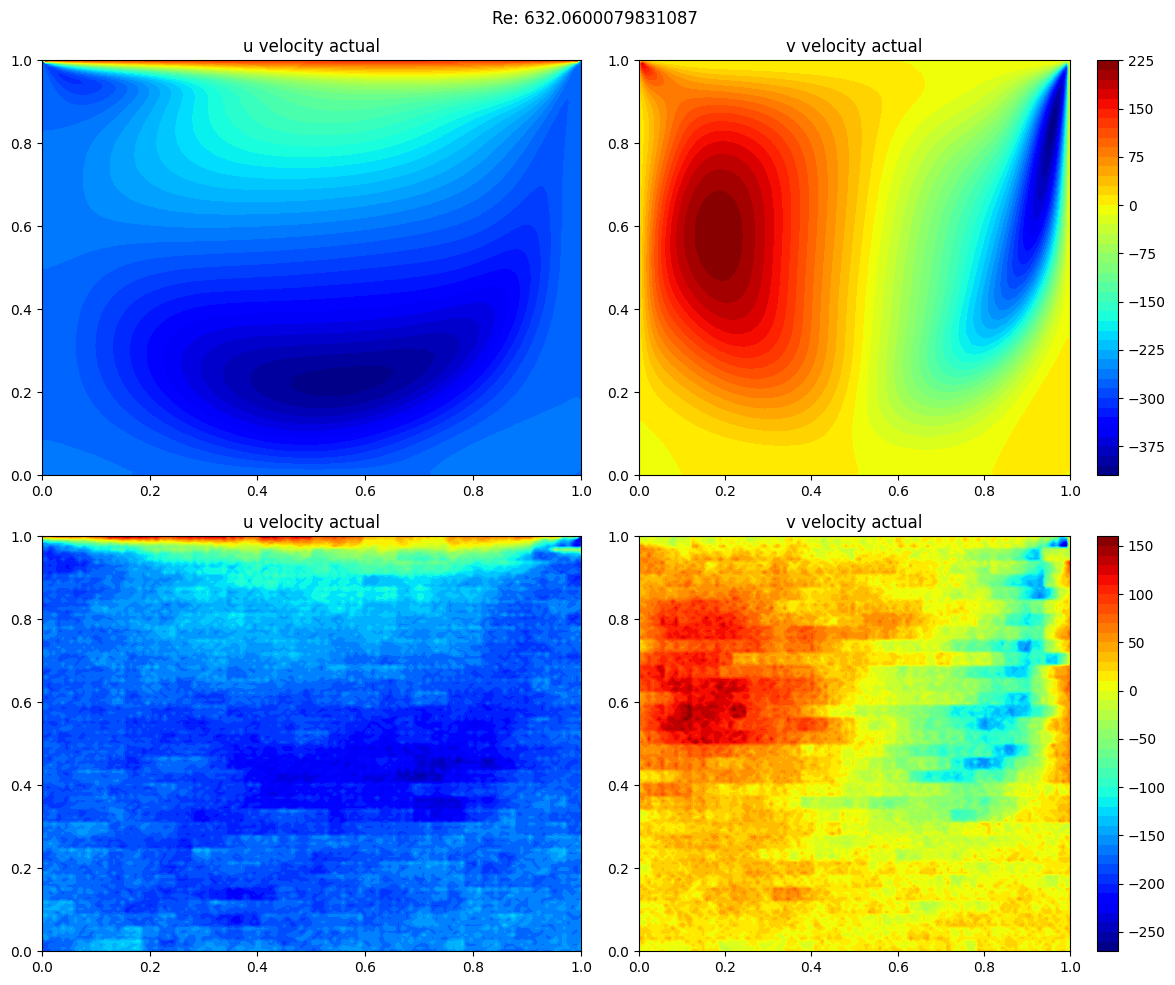

In [11]:
patches = tgt[0] # remove B for now
re = src[0]      # remove B for now

unrolled_actual = patches_to_contour(patches, config["grid_size"]//config["patch_size"], config["patch_size"], config["grid_size"])
unrolled_pred = patches_to_contour(pred_patches[0], config["grid_size"]//4, 4, config["grid_size"])

u_actual = unrolled_actual[0]                                                 # (grid_size, grid_size)
v_actual = unrolled_actual[1]                                                 # (grid_size, grid_size)

u_pred = unrolled_pred[0]                                                 # (grid_size, grid_size)
v_pred = unrolled_pred[1]                                                 # (grid_size, grid_size)

x_grid = torch.linspace(0, 1, 128)
y_grid = torch.linspace(0, 1, 128)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].contourf(x_grid, y_grid, (u_actual * cfd_dataset.u_std) + cfd_dataset.u_mean, levels=50, cmap="jet")
axes[0, 0].set_title("u velocity actual")
c1 = axes[0, 1].contourf(x_grid, y_grid, (v_actual * cfd_dataset.v_std) + cfd_dataset.v_mean, levels=50, cmap="jet")
fig.colorbar(c1)
axes[0, 1].set_title("v velocity actual")

axes[1, 0].contourf(x_grid, y_grid, ((u_pred * cfd_dataset.u_std) + cfd_dataset.u_mean).detach().cpu().numpy(), levels=50, cmap="jet")
axes[1, 0].set_title("u velocity actual")
c2 = axes[1, 1].contourf(x_grid, y_grid, ((v_pred * cfd_dataset.v_std) + cfd_dataset.v_mean).detach().cpu().numpy(), levels=50, cmap="jet")
fig.colorbar(c2)
axes[1, 1].set_title("v velocity actual")


plt.suptitle(f"Re: {(re.item() * cfd_dataset.re_std) + cfd_dataset.re_mean}")

plt.tight_layout()
plt.show()

Max divergence actual: 2.7353523
Max divergence pred: 1.1056279

Mean divergence actual: 0.038896836
Mean divergence pred: 0.038896836


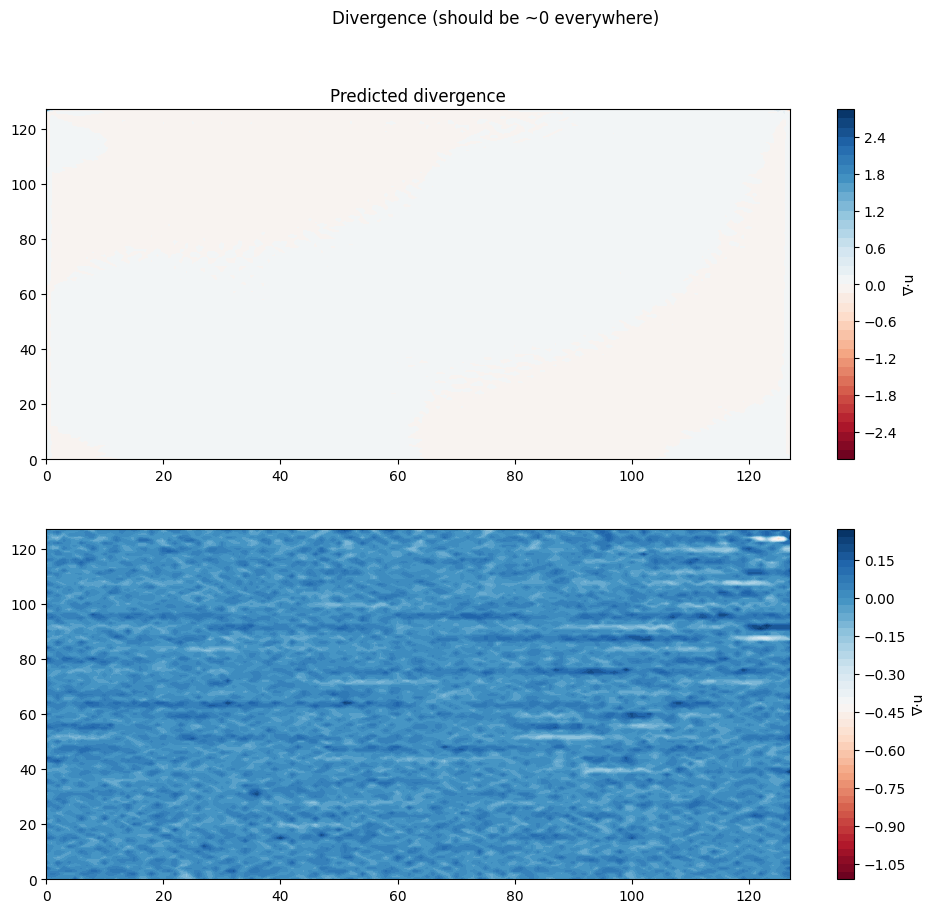

In [12]:
u_np = u_actual.detach().numpy()
v_np = v_actual.detach().numpy()

u_np_pred = u_pred.detach().numpy()
v_np_pred = v_pred.detach().numpy()

# numerical gradients
du_dx = np.gradient(u_np, axis=1)  # derivative along x (cols)
dv_dy = np.gradient(v_np, axis=0)  # derivative along y (rows)

du_dx_pred = np.gradient(u_np_pred, axis=1)  # derivative along x (cols)
dv_dy_pred = np.gradient(v_np_pred, axis=0)  # derivative along y (rows)

divergence = du_dx + dv_dy
divergence_pred = du_dx_pred + dv_dy_pred

print("Max divergence actual:", np.abs(divergence).max())
print("Max divergence pred:", np.abs(divergence_pred).max())

print("\nMean divergence actual:", np.abs(divergence_pred).mean())
print("Mean divergence pred:", np.abs(divergence_pred).mean())

fig, axes = plt.subplots(2, figsize=(12, 10))

c1 = axes[0].contourf(divergence, levels=50, cmap="RdBu")
axes[0].set_title("Actual divergence")
plt.colorbar(c1, label="∇·u")

c2 = axes[1].contourf(divergence_pred, levels=50, cmap="RdBu")
axes[0].set_title("Predicted divergence")
plt.colorbar(c2, label="∇·u")

plt.suptitle("Divergence (should be ~0 everywhere)")
plt.show()

100%|██████████| 1024/1024 [03:11<00:00,  5.34it/s]


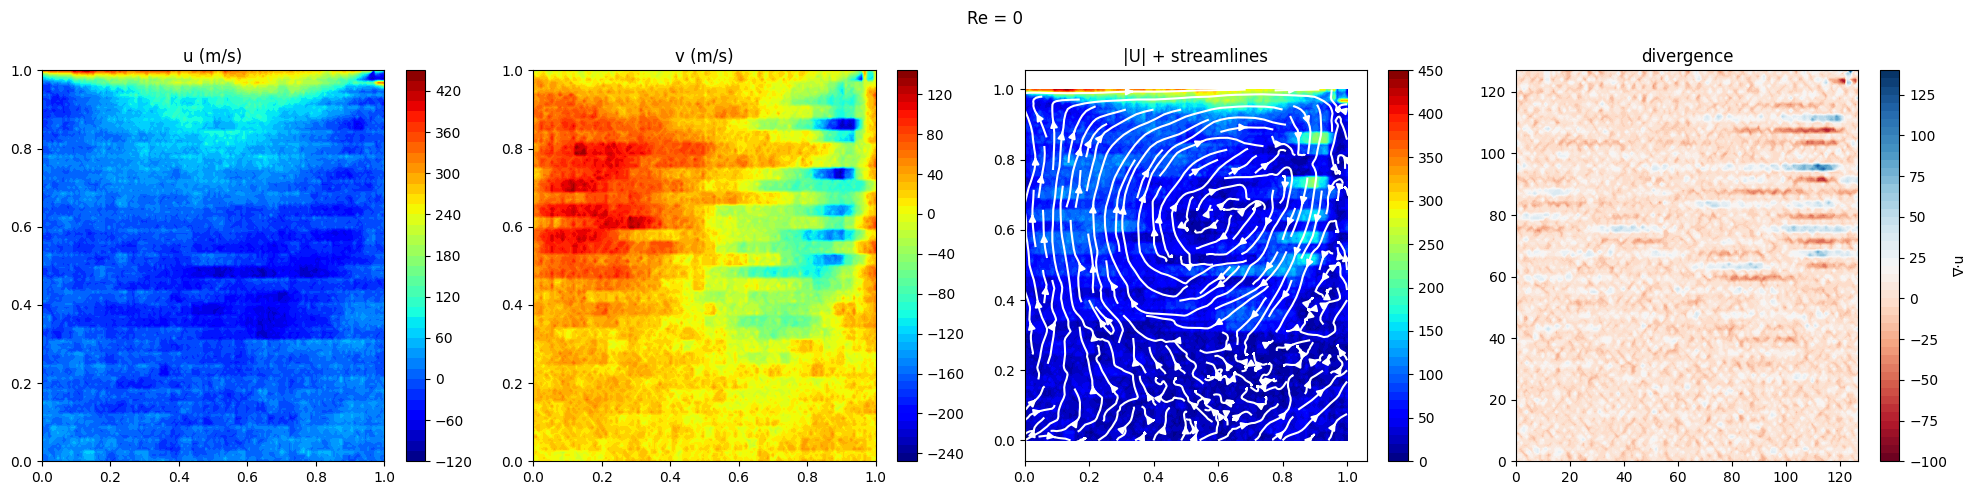

100%|██████████| 1024/1024 [04:25<00:00,  3.85it/s]


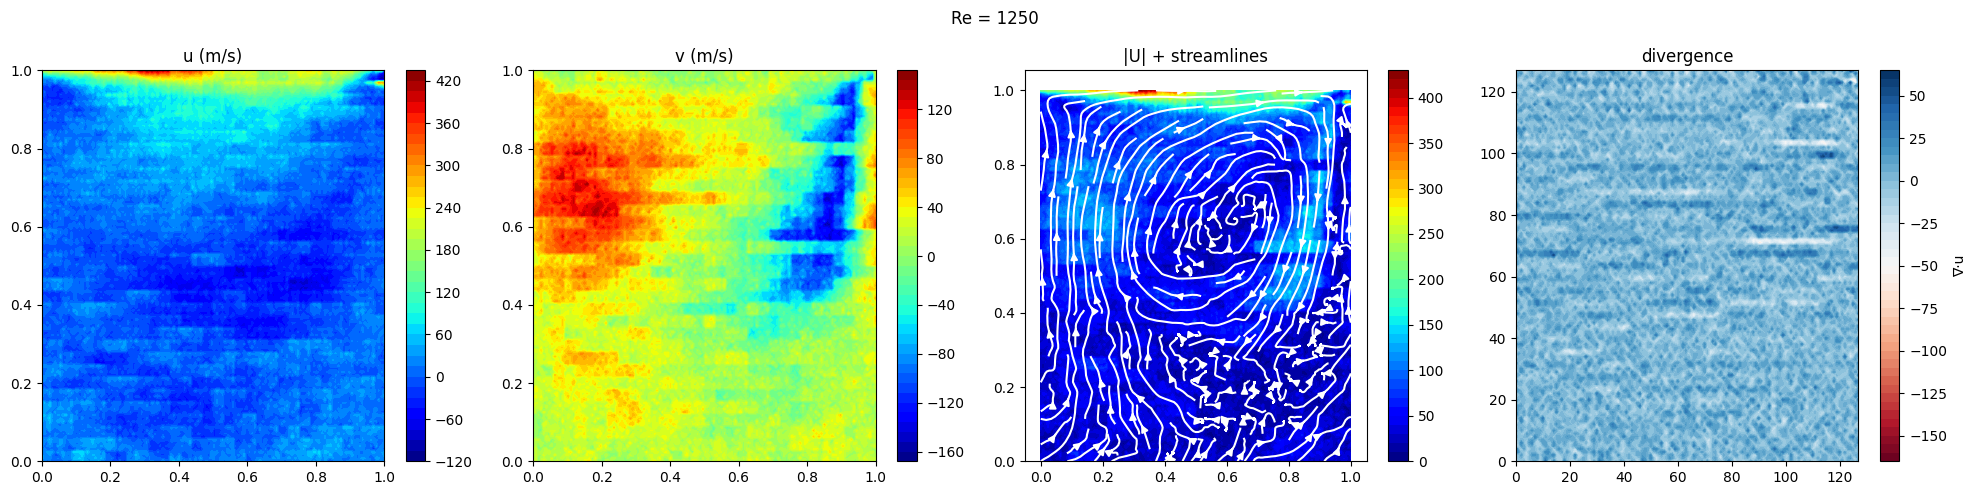

 96%|█████████▌| 985/1024 [03:38<00:22,  1.75it/s]

In [ ]:
def predict_for_re(re_value, model, cfd_dataset, config, device="cpu"):
    # normalize using dataset stats
    re_norm = (re_value - cfd_dataset.re_mean) / cfd_dataset.re_std
    src = torch.tensor([[re_norm]], dtype=torch.float32).to(device)  # (1, 1)

    # decode
    src_mask = make_src_mask(src, -1)
    pred_patches = greedy_decode(
        model, src, src_mask,
        max_len  = (config["grid_size"] // config["patch_size"])**2,
        patch_dim = config["patch_dim"],
        device   = device
    )  # (1, num_patches, patch_dim)

    # unroll patches to (2, 64, 64)
    unrolled = patches_to_contour(pred_patches[0], 
                                   config["grid_size"] // config["patch_size"], 
                                   config["patch_size"], 
                                   config["grid_size"])

    u = unrolled[0].detach().cpu()
    v = unrolled[1].detach().cpu()

    # denormalize
    u = (u * cfd_dataset.u_std) + cfd_dataset.u_mean
    v = (v * cfd_dataset.v_std) + cfd_dataset.v_mean

    # plot
    x_grid = np.linspace(0, 1, config["grid_size"])
    y_grid = np.linspace(0, 1, config["grid_size"])

    mag = np.sqrt(u**2 + v**2)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    c0 = axes[0].contourf(x_grid, y_grid, u, levels=50, cmap="jet")
    fig.colorbar(c0, ax=axes[0])
    axes[0].set_title("u (m/s)")

    c1 = axes[1].contourf(x_grid, y_grid, v, levels=50, cmap="jet")
    fig.colorbar(c1, ax=axes[1])
    axes[1].set_title("v (m/s)")

    c2 = axes[2].contourf(x_grid, y_grid, mag, levels=50, cmap="jet")
    fig.colorbar(c2, ax=axes[2])
    axes[2].streamplot(x_grid, y_grid, u.numpy(), v.numpy(), color="white", density=1.2)
    axes[2].set_title("|U| + streamlines")

    # numerical gradients
    u_np = u.numpy()
    v_np = v.numpy()
    du_dx = np.gradient(u_np, axis=1)  # derivative along x (cols)
    dv_dy = np.gradient(v_np, axis=0)  # derivative along y (rows)

    divergence = du_dx + dv_dy

    c3 = axes[3].contourf(divergence, levels=50, cmap="RdBu")
    plt.colorbar(c3, label="∇·u")
    axes[3].set_title("divergence")

    plt.suptitle(f"Re = {re_value}")
    plt.tight_layout()
    plt.show()

    return u, v, divergence

# Re can be inside or outside training range
u, v, divergence = predict_for_re(0, transformer, cfd_dataset, config, device=config["device"])
u, v, divergence = predict_for_re(1250, transformer, cfd_dataset, config, device=config["device"])
u, v, divergence = predict_for_re(2500,  transformer, cfd_dataset, config, device=config["device"])

In [40]:
divergence.min()

-332.8983